In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import copy

### Load the data

In [2]:
case = 't_hom_9ms_aniso_uvp_nosgs'
path_to_data = '/scratch/general/nfs1/u1450851/LES_Sims/'+case+'/'
iteration = 90000

In [3]:
data_mom = xr.open_dataarray(path_to_data + 'data/Momentum3D/Data_Momentum_'+str(iteration)+'.nc')
data_sc = xr.open_dataarray(path_to_data + 'data/Scalar3D/Data_Scalar_'+str(iteration)+'.nc')
data_aniso = xr.open_dataarray(path_to_data + 'data/Anisotropy/Data_Anisotropy_'+str(iteration)+'.nc')

### Simulation parameters

In [4]:
nx = ny = nz = 64
lx = ly = 2*np.pi
lz = 2
dx = dy = lx/nx
dz = lz/nz

zi = 1000
uscale = 0.4
Tscale = 290

x = np.arange(0,nx)*dx
y = np.arange(0,ny)*dy
z_uvp = np.arange(0,nz)*dz + dz/2
z_w = np.arange(0,nz)*dz

### Some functions

In [5]:
def get_dphidx(phi, wn):
  phi_c = np.fft.rfft(phi, axis=0, norm="ortho")
  dphidx_c = complex(0, 1) * wn[:, np.newaxis, np.newaxis] * phi_c
  dphidx_c[-1, :, :] = 0
  return np.fft.irfft(dphidx_c, axis=0, norm="ortho")

def get_dphidy(phi, wn):
  phi_c = np.fft.rfft(phi, axis=1, norm="ortho")
  dphidy_c = complex(0, 1) * wn[np.newaxis, :, np.newaxis] * phi_c
  dphidy_c[:, -1, :] = 0
  return np.fft.irfft(dphidy_c, axis=1, norm="ortho")

def get_dphidz(phi, dz):
  dphidz = np.zeros(phi.shape)
  dphidz[:,:,:-1] = (phi[:,:,1:]-phi[:,:,:-1]) / (dz)
  dphidz[:,:,-1] = dphidz[:,:,-2]
  return dphidz

def uvpnode2wnode(phi_c):
  phi_h = np.zeros(phi_c.shape)
  phi_h[:, :, 0] = 0
  phi_h[:, :, 1:] = 0.5*(phi_c[:, :, :-1] + phi_c[:, :, 1:])
  return phi_h

def wnode2uvpnode(phi_h):
  phi_c = np.zeros(phi_h.shape)
  phi_c[:, :, :-1] = 0.5*(phi_h[:, :, :-1]+phi_h[:, :, 1:])
  phi_c[:, :, -1] = phi_h[:, :, -1]
  return phi_c

### Some preliminary analyis

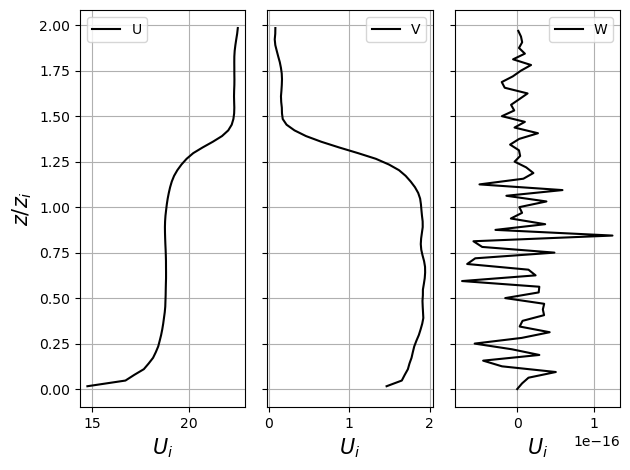

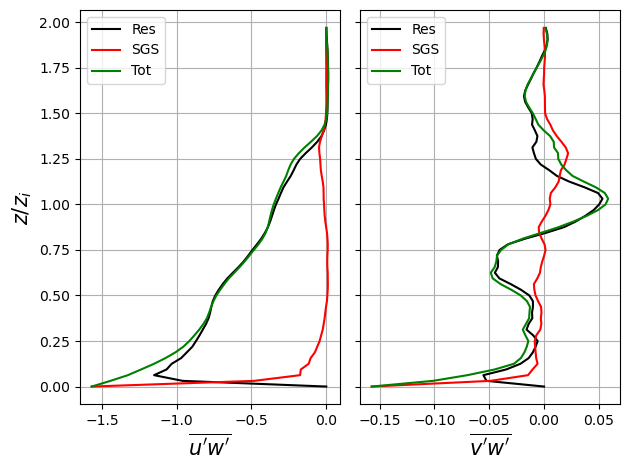

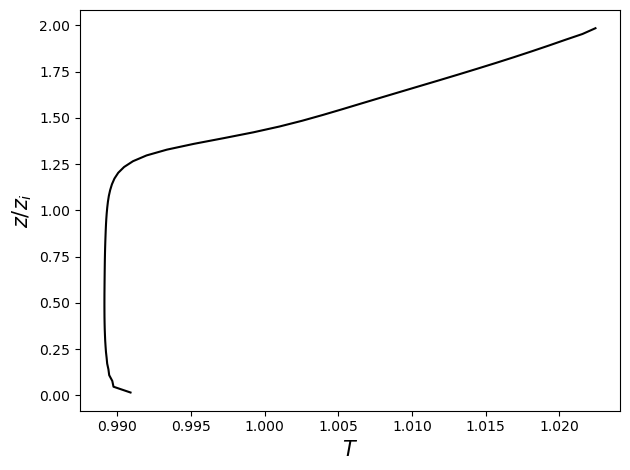

In [6]:
#Plot some vertical profiles of mean velocity, shera stress, temperature

#three components of velocity
fig,axs = plt.subplots(1,3,tight_layout=True,sharey=True)

axs[0].plot(np.mean(data_mom[:,:,:,0],axis=(0,1)),z_uvp,'k',label='U')
axs[1].plot(np.mean(data_mom[:,:,:,1],axis=(0,1)),z_uvp,'k',label='V')
axs[2].plot(np.mean(data_mom[:,:,:,2],axis=(0,1)),z_w,'k',label='W')

for i in range(len(axs)):
    axs[i].legend()
    axs[i].grid()
    # axs[i].set_ylim(0,1)
    axs[i].set_xlabel(r"$U_i$",fontsize=15)

axs[0].set_ylabel(r"$z/z_i$",fontsize = 15)

plt.show()

#shear stress
shear_uw_res = data_mom[:,:,:,14] - uvpnode2wnode(data_mom[:,:,:,0])*data_mom[:,:,:,2]
shear_vw_res = data_mom[:,:,:,15] - uvpnode2wnode(data_mom[:,:,:,1])*data_mom[:,:,:,2]
shear_uw_sgs = data_mom[:,:,:,20]
shear_vw_sgs = data_mom[:,:,:,21]
shear_uw_tot = shear_uw_res - shear_uw_sgs
shear_vw_tot = shear_vw_res - shear_vw_sgs

fig,axs = plt.subplots(1,2,tight_layout=True,sharey=True)

axs[0].plot(np.mean(shear_uw_res,axis=(0,1)),z_w,'k',label='Res')
axs[0].plot(np.mean(-shear_uw_sgs,axis=(0,1)),z_w,'r',label='SGS')
axs[0].plot(np.mean(shear_uw_tot,axis=(0,1)),z_w,'g',label='Tot')

axs[1].plot(np.mean(shear_vw_res,axis=(0,1)),z_w,'k',label='Res')
axs[1].plot(np.mean(-shear_vw_sgs,axis=(0,1)),z_w,'r',label='SGS')
axs[1].plot(np.mean(shear_vw_tot,axis=(0,1)),z_w,'g',label='Tot')

axs[0].set_xlabel(r"$\overline{u'w'}$",fontsize=15)
axs[1].set_xlabel(r"$\overline{v'w'}$",fontsize=15)
axs[0].set_ylabel(r"$z/z_i$",fontsize=15)
# axs[0].set_ylim(0,1)

for i in range(len(axs)):
    axs[i].legend()
    axs[i].grid()

plt.show()

fig,axs = plt.subplots(1,1,tight_layout=True)

axs.plot(np.mean(data_sc[:,:,:,0],axis=(0,1)),z_uvp,'k',label='T')
axs.set_ylabel(r"$z/z_i$",fontsize=15)
axs.set_xlabel(r"$T$",fontsize=15)

plt.show()

In [7]:
#Plot turbulence anisotropy
os.chdir("/uufs/chpc.utah.edu/common/home/u1450851/Python_Codes/functions/")

from Anisotropy_Functions import ColorAnisotropy

xB = data_aniso[:,:,:,0]
yB = data_aniso[:,:,:,1]

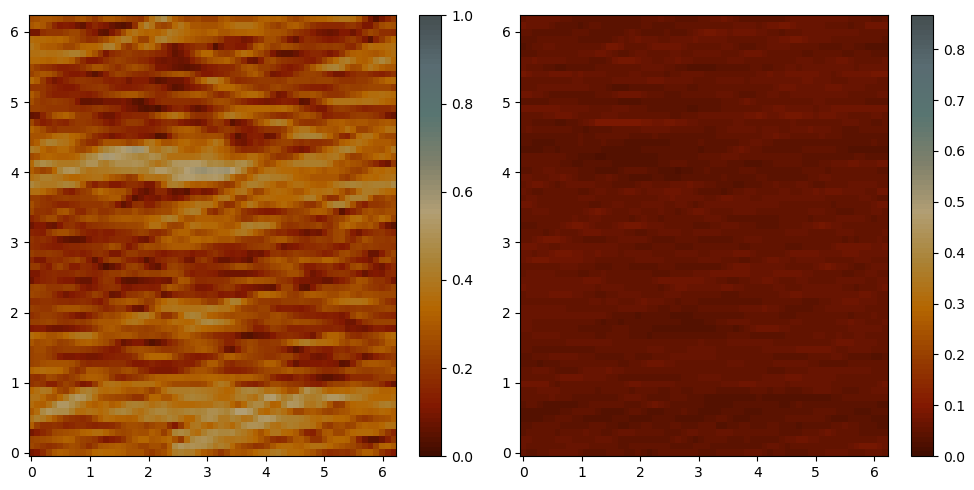

In [8]:
cmap=ColorAnisotropy()
zslice=0

fig,axs = plt.subplots(1,2,tight_layout=True,figsize=(10,5))

p1 = axs[0].pcolormesh(x,y,xB[:,:,zslice].T,cmap=cmap,vmin=0,vmax=1)
p2 = axs[1].pcolormesh(x,y,yB[:,:,zslice].T,cmap=cmap,vmin=0,vmax=np.sqrt(3)/2)

cbar1 = plt.colorbar(p1)
cbar2 = plt.colorbar(p2)

plt.show()

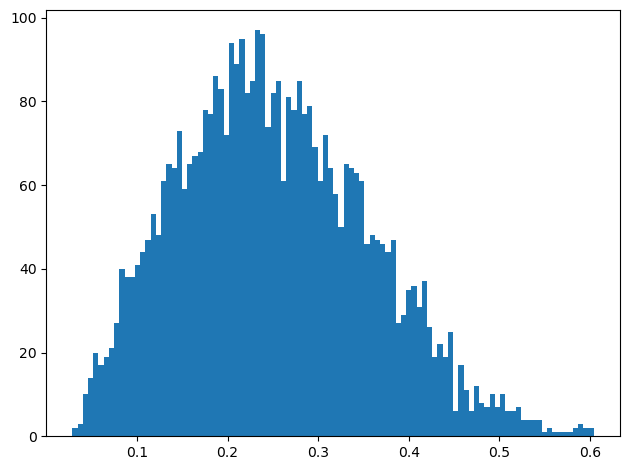

In [9]:
fig,axs = plt.subplots(1,1,tight_layout=True)

axs.hist(xB[:,:,0].values.flatten(),bins=100)

plt.show()

### Load Checkpoint Data

In [10]:
os.chdir('/uufs/chpc.utah.edu/common/home/u1450851/Python_Codes/functions/')

from read_checkpoint_SC import read_checkpoint

from read_checkpoint_SC import read_checkpoint_sfc

In [11]:
check_step = 90000

data_check = read_checkpoint(path_to_data + '/output_checkpoint/',[check_step],nx,ny,nz)

In [12]:
data_check.keys()

dict_keys(['u', 'v', 'w', 'RHSx', 'RHSy', 'RHSz', 'Cs_opt2', 'F_LM', 'F_MM', 'F_QN', 'F_NN', 'SC', 'sc_new', 'wsc_new', 'tsw_new', 'RHSsc', 'Ds_opt2', 'F_KX', 'F_XX', 'F_PY', 'F_YY', 'u_new', 'v_new', 'w_new', 'uu_new', 'vv_new', 'ww_new', 'uv_new', 'uw_new', 'vw_new', 'txx_new', 'tyy_new', 'tzz_new', 'txy_new', 'txz_new', 'tyz_new'])

### Checkpoint data analysis

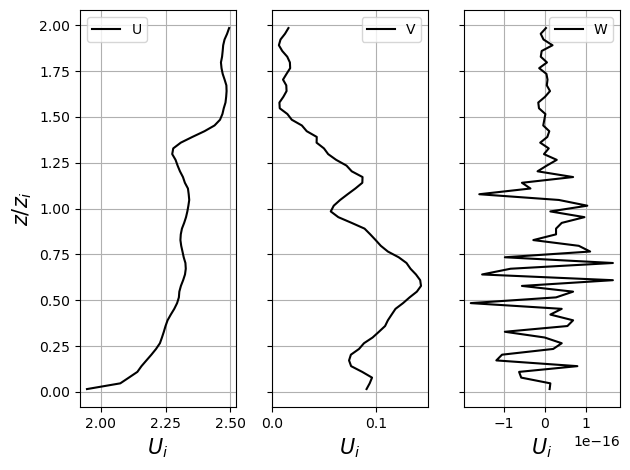

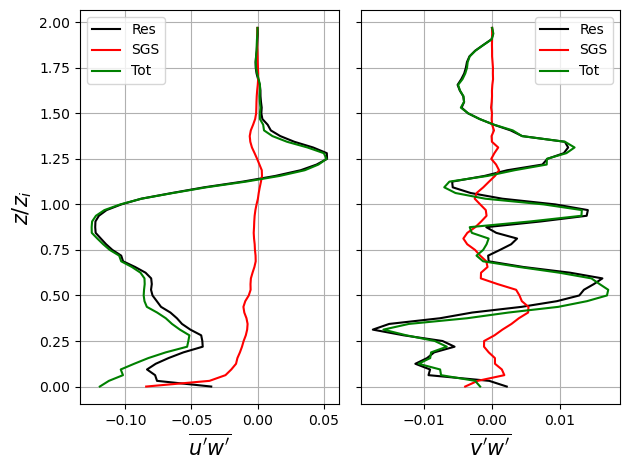

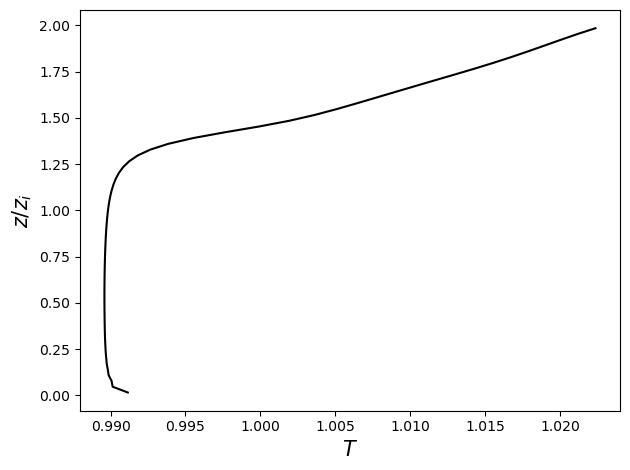

In [13]:
fig,axs = plt.subplots(1,3,tight_layout=True,sharey=True)

axs[0].plot(np.mean(data_check['u_new'][:,:,:-1],axis=(0,1)),z_uvp,'k',label='U')
axs[1].plot(np.mean(data_check['v_new'][:,:,:-1],axis=(0,1)),z_uvp,'k',label='V')
axs[2].plot(np.mean(data_check['w_new'][:,:,:-1],axis=(0,1)),z_uvp,'k',label='W')

for i in range(len(axs)):
    axs[i].legend()
    axs[i].grid()
    # axs[i].set_ylim(0,1)
    axs[i].set_xlabel(r"$U_i$",fontsize=15)

axs[0].set_ylabel(r"$z/z_i$",fontsize = 15)

plt.show()

# #shear stress
shear_uw_res = data_check['uw_new'][:,:,:-1] - (data_check['u_new'][:,:,:-1])*data_check['w_new'][:,:,:-1]
shear_vw_res = data_check['vw_new'][:,:,:-1] - (data_check['v_new'][:,:,:-1])*data_check['w_new'][:,:,:-1]
shear_uw_sgs = data_check['txz_new'][:,:,:-1]
shear_vw_sgs = data_check['txy_new'][:,:,:-1]
shear_uw_tot = shear_uw_res - shear_uw_sgs
shear_vw_tot = shear_vw_res - shear_vw_sgs

fig,axs = plt.subplots(1,2,tight_layout=True,sharey=True)

axs[0].plot(np.mean(shear_uw_res,axis=(0,1)),z_w,'k',label='Res')
axs[0].plot(np.mean(-shear_uw_sgs,axis=(0,1)),z_w,'r',label='SGS')
axs[0].plot(np.mean(shear_uw_tot,axis=(0,1)),z_w,'g',label='Tot')

axs[1].plot(np.mean(shear_vw_res,axis=(0,1)),z_w,'k',label='Res')
axs[1].plot(np.mean(-shear_vw_sgs,axis=(0,1)),z_w,'r',label='SGS')
axs[1].plot(np.mean(shear_vw_tot,axis=(0,1)),z_w,'g',label='Tot')

axs[0].set_xlabel(r"$\overline{u'w'}$",fontsize=15)
axs[1].set_xlabel(r"$\overline{v'w'}$",fontsize=15)
axs[0].set_ylabel(r"$z/z_i$",fontsize=15)
# axs[0].set_ylim(0,1)

for i in range(len(axs)):
    axs[i].legend()
    axs[i].grid()

plt.show()

fig,axs = plt.subplots(1,1,tight_layout=True)

axs.plot(np.mean(data_check['sc_new'][:,:,:-1],axis=(0,1)),z_uvp,'k',label='T')
axs.set_ylabel(r"$z/z_i$",fontsize=15)
axs.set_xlabel(r"$T$",fontsize=15)

plt.show()

In [14]:
#Compute the REynods stress terms

Rxx = data_check['uu_new'][:,:,:-1] - data_check['u_new'][:,:,:-1]*data_check['u_new'][:,:,:-1]
Ryy = data_check['vv_new'][:,:,:-1] - data_check['v_new'][:,:,:-1]*data_check['v_new'][:,:,:-1]
Rzz = data_check['ww_new'][:,:,:-1] - data_check['w_new'][:,:,:-1]*data_check['w_new'][:,:,:-1]
Rxy = data_check['uv_new'][:,:,:-1] - data_check['u_new'][:,:,:-1]*data_check['v_new'][:,:,:-1]
Rxz = data_check['uw_new'][:,:,:-1] - data_check['u_new'][:,:,:-1]*data_check['w_new'][:,:,:-1]
Ryz = data_check['vw_new'][:,:,:-1] - data_check['v_new'][:,:,:-1]*data_check['w_new'][:,:,:-1]

txx = data_check['txx_new'][:,:,:-1]
tyy = data_check['tyy_new'][:,:,:-1]
tzz = data_check['tzz_new'][:,:,:-1]
txy = data_check['txy_new'][:,:,:-1]
txz = data_check['txz_new'][:,:,:-1]
tyz = data_check['tyz_new'][:,:,:-1]

In [26]:
#Compute anisotropy 

os.chdir("/uufs/chpc.utah.edu/common/home/u1450851/Python_Codes/functions/")

from Anisotropy_Functions import ColorAnisotropy, Anisotropy_Clustering, Anisotropy

[xB_c,yB_c,l] = Anisotropy(nx,ny,nz,Rxx,Ryy,Rzz,Rxy-txy,Rxz-txz,Ryz-tyz)

iteration = 0
iteration = 1
iteration = 2
iteration = 3
iteration = 4
iteration = 5
iteration = 6
iteration = 7
iteration = 8
iteration = 9
iteration = 10
iteration = 11
iteration = 12
iteration = 13
iteration = 14
iteration = 15
iteration = 16
iteration = 17
iteration = 18
iteration = 19
iteration = 20
iteration = 21
iteration = 22
iteration = 23
iteration = 24
iteration = 25
iteration = 26
iteration = 27
iteration = 28
iteration = 29
iteration = 30
iteration = 31
iteration = 32
iteration = 33
iteration = 34
iteration = 35
iteration = 36
iteration = 37
iteration = 38
iteration = 39
iteration = 40
iteration = 41
iteration = 42
iteration = 43
iteration = 44
iteration = 45
iteration = 46
iteration = 47
iteration = 48
iteration = 49
iteration = 50
iteration = 51
iteration = 52
iteration = 53
iteration = 54
iteration = 55
iteration = 56
iteration = 57
iteration = 58
iteration = 59
iteration = 60
iteration = 61
iteration = 62
iteration = 63


In [27]:
np.any(yB_c[:,:,:]<0)

True

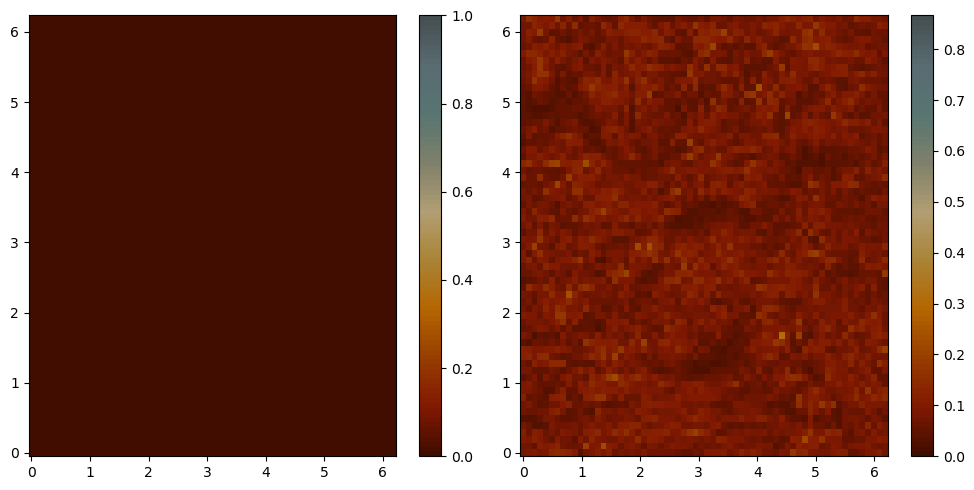

In [61]:
cmap=ColorAnisotropy()
zslice=0

fig,axs = plt.subplots(1,2,tight_layout=True,figsize=(10,5))

p1 = axs[0].pcolormesh(x,y,abs(xB_c[:,:,zslice] - xB[:,:,zslice]).T,cmap=cmap,vmin=0,vmax=1)
p2 = axs[1].pcolormesh(x,y,yB_c[:,:,zslice].T,cmap=cmap,vmin=0,vmax=np.sqrt(3)/2)

cbar1 = plt.colorbar(p1)
cbar2 = plt.colorbar(p2)

plt.show()

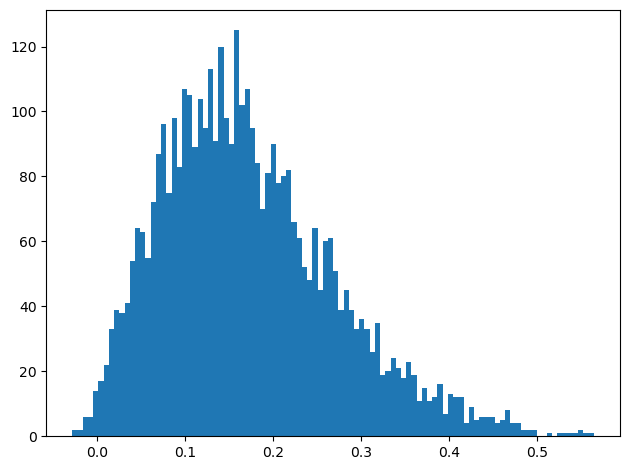

In [23]:
fig,axs = plt.subplots(1,1,tight_layout=True)

axs.hist(xB_c[:,:,0].flatten(),bins=100)

plt.show()

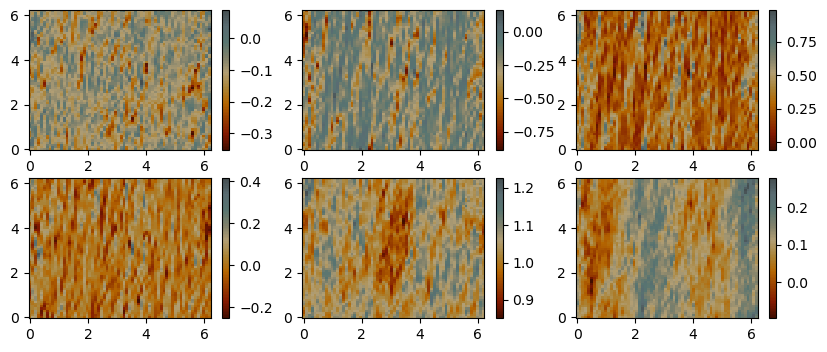

In [28]:
fig,axs = plt.subplots(2,3,figsize=(10,4))

p1 = axs[0,0].pcolormesh(x,y,txx[:,:,0],cmap=cmap)
p2 = axs[0,1].pcolormesh(x,y,tyy[:,:,0],cmap=cmap)
p3 = axs[0,2].pcolormesh(x,y,tzz[:,:,0],cmap=cmap)
p4 = axs[1,0].pcolormesh(x,y,txy[:,:,0],cmap=cmap)
p5 = axs[1,1].pcolormesh(x,y,txz[:,:,0],cmap=cmap)
p6 = axs[1,2].pcolormesh(x,y,tyz[:,:,0],cmap=cmap)

cbar = plt.colorbar(p1)
cbar = plt.colorbar(p2)
cbar = plt.colorbar(p3)
cbar = plt.colorbar(p4)
cbar = plt.colorbar(p5)
cbar = plt.colorbar(p6)

plt.show()

In [29]:
trace = txx + tyy + tzz

In [33]:
np.mean(-trace,axis=(0,1))

array([ 2.42600824e-17,  3.53528093e-17,  1.38699377e-17,  2.74284406e-19,
       -1.58120934e-17, -1.36421340e-17,  3.33718739e-18,  1.24844947e-17,
       -1.98946822e-17, -1.02147558e-17,  3.03477512e-18, -6.29835336e-18,
       -4.00215623e-18,  8.31835985e-18,  1.65855420e-18, -3.51818112e-19,
       -1.00831319e-17, -1.31797566e-17,  1.70170243e-18,  6.82758636e-18,
        1.03579755e-17,  3.19577714e-18,  7.30391713e-18,  1.49662895e-18,
       -1.91601003e-18,  8.27939303e-18,  1.03193007e-17, -1.40812610e-19,
       -8.62697349e-18, -1.99722552e-18,  3.67487085e-18, -8.69077476e-18,
        3.38149366e-19,  2.65521254e-18,  3.44679316e-18,  2.03164078e-18,
        9.07546834e-18, -5.90452833e-18,  1.78238014e-18, -2.45427962e-18,
       -2.94544540e-18,  1.78009289e-18, -1.02714915e-18,  5.59938719e-19,
        6.74773515e-19, -9.06912810e-19,  4.66715878e-19, -3.59225231e-19,
       -1.50358688e-20,  3.05700725e-19, -1.26753848e-19,  1.18718533e-18,
       -7.21413474e-19,  